In [1]:
import os
import json
from matplotlib import pyplot as plt
import numpy as np

info_fn = "/mnt/sdc/data/err_empty_syn/check_empty_mask_v0.1.0.json"
with open(info_fn, "r") as fp:
    info = json.load(fp)
print(f"Loaded {len(info)} frames")
print(info[0])

Loaded 367424 frames
{'div_fix_but_changed': 0.3038140203039651, 'fix_but_changed': 34149, 'both_fixed': 112401}


In [2]:
div_fix_but_changed = np.array([c["div_fix_but_changed"] for c in info if c is not None])
fix_but_changed = np.array([c["fix_but_changed"] for c in info if c is not None])
both_fixed = np.array([c["both_fixed"] for c in info if c is not None])
print(f"{len(div_fix_but_changed)} valid frames")

367423 valid frames


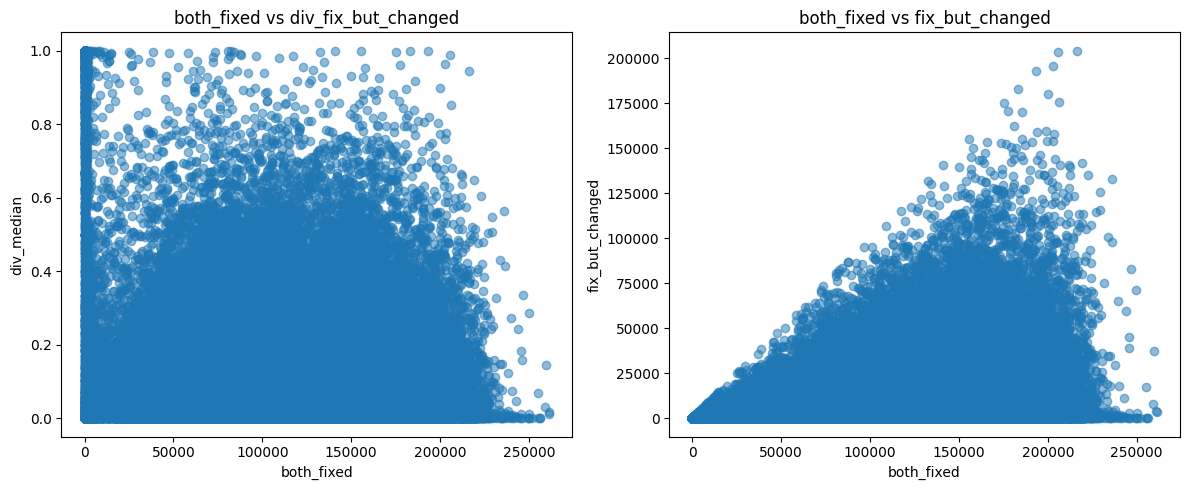

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(both_fixed, div_fix_but_changed, alpha=0.5)
axes[0].set_xlabel('both_fixed')
axes[0].set_ylabel('div_median')
axes[0].set_title('both_fixed vs div_fix_but_changed')

axes[1].scatter(both_fixed, fix_but_changed, alpha=0.5)
axes[1].set_xlabel('both_fixed')
axes[1].set_ylabel('fix_but_changed')
axes[1].set_title('both_fixed vs fix_but_changed')

plt.tight_layout()
plt.show()

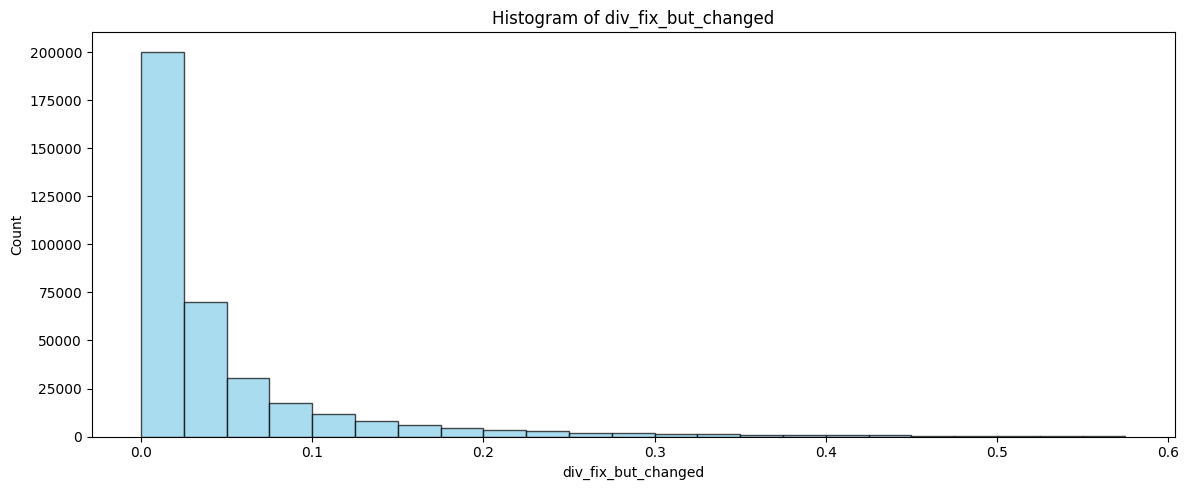

In [9]:
bins = np.arange(0.0, 0.6, 0.025)
bins = np.append(bins, np.inf)      # rightmost bin: >0.6

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(div_fix_but_changed, bins=bins, alpha=0.7, color='skyblue', edgecolor='black')
ax.set_title('Histogram of div_fix_but_changed')
ax.set_xlabel('div_fix_but_changed')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


In [12]:
high_thresh = 0.05
select_idxs = (div_fix_but_changed < high_thresh)
print(f"select {select_idxs.sum()} frames")

select 270160 frames
